# Titanic Clustering: K-Means & Hierarchical

In [2]:
%pip install matplotlib scikit-learn scipy pandas numpy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import dendrogram, linkage


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [13]:
df = pd.read_csv('TitanicDataset.csv')
display(df.head())
print(df.isnull().sum())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [14]:
df = df.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'])

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

df = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(df), columns=df.columns)

X = StandardScaler().fit_transform(df)

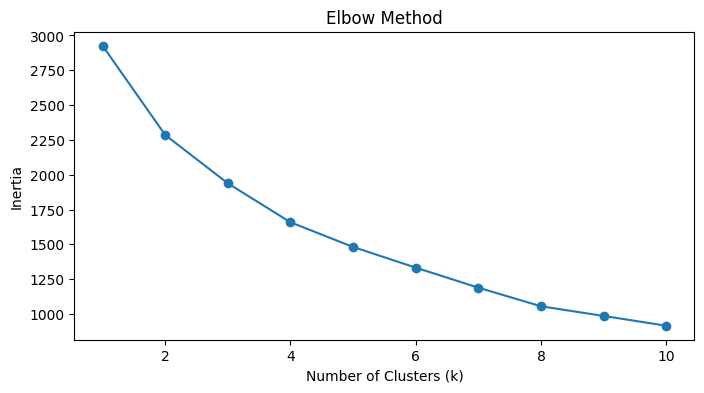

In [15]:
inertias = [KMeans(n_clusters=i, random_state=42, n_init=10).fit(X).inertia_ for i in range(1, 11)]

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

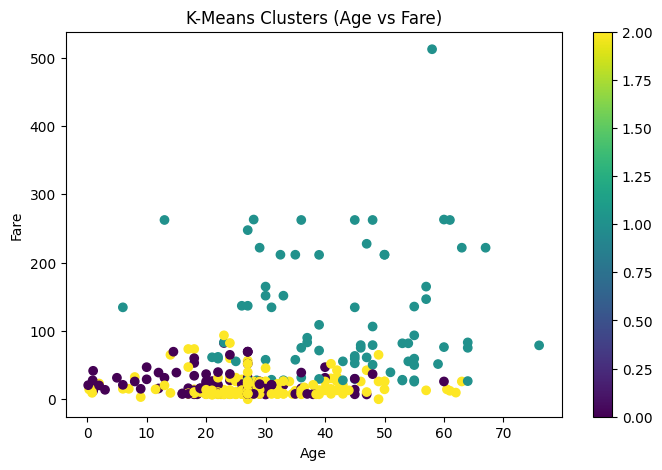

In [16]:
k = 3
labels_km = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)

plt.figure(figsize=(8, 5))
sc = plt.scatter(df['Age'], df['Fare'], c=labels_km, cmap='viridis')
plt.colorbar(sc)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('K-Means Clusters (Age vs Fare)')
plt.show()

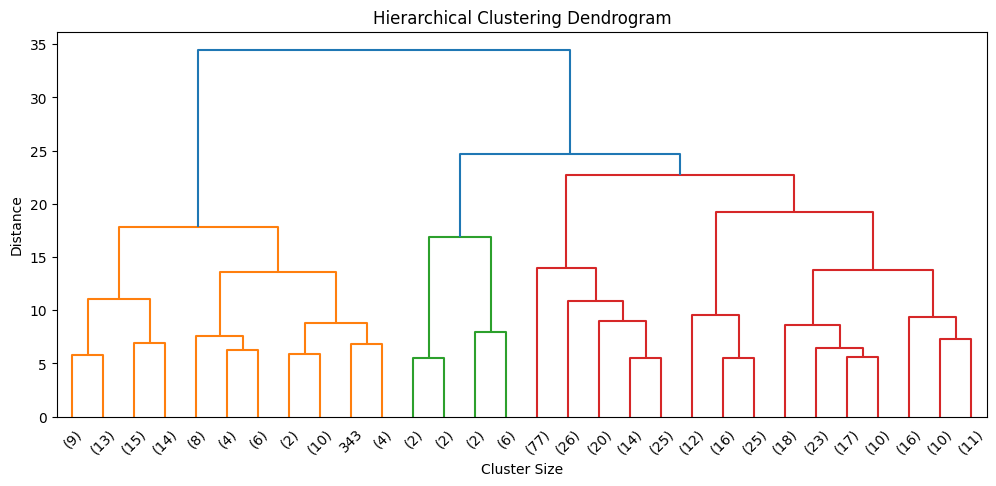

In [17]:
linked = linkage(X, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

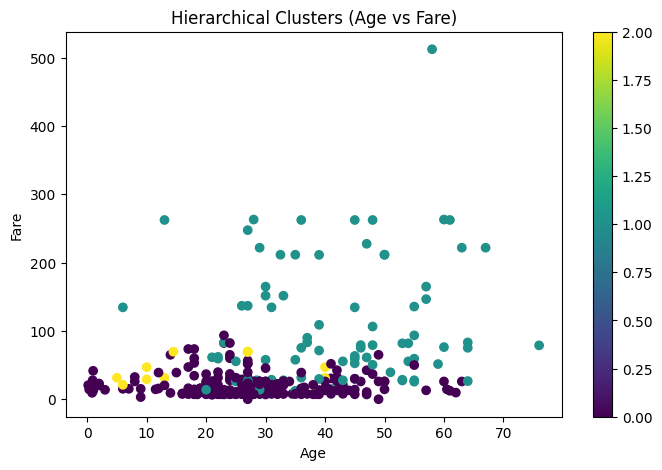

In [18]:
labels_hc = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)

plt.figure(figsize=(8, 5))
sc = plt.scatter(df['Age'], df['Fare'], c=labels_hc, cmap='viridis')
plt.colorbar(sc)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Hierarchical Clusters (Age vs Fare)')
plt.show()